# Effect of sample size in cross-validation

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
data, target = housing.data, housing.target
target *= 100  # rescale the target in k$

In [2]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

In [3]:
import numpy as np

train_sizes = np.linspace(0.1, 1.0, num=5, endpoint=True)
train_sizes

array([0.1  , 0.325, 0.55 , 0.775, 1.   ])

In [4]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=30, test_size=0.2)

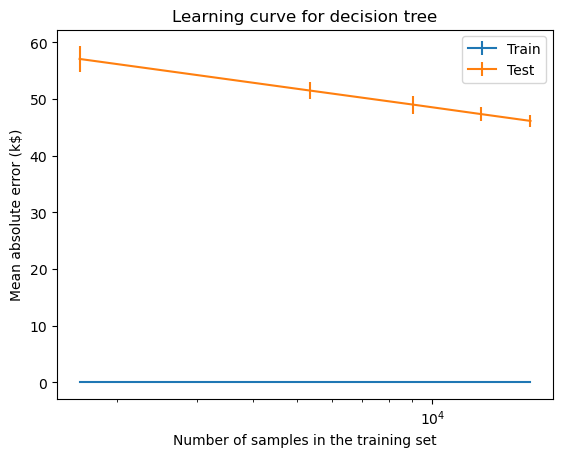

In [5]:
from sklearn.model_selection import LearningCurveDisplay

display = LearningCurveDisplay.from_estimator(
    regressor,
    data,
    target,
    train_sizes=train_sizes,
    cv=cv,
    score_type="both",  # both train and test errors
    scoring="neg_mean_absolute_error",
    negate_score=True,  # to use when metric starts with "neg_"
    score_name="Mean absolute error (k$)",
    std_display_style="errorbar",
    n_jobs=2,
)
_ = display.ax_.set(xscale="log", title="Learning curve for decision tree")

**Learning curve :** a visual representation of the capacity of a model to improve by adding new samples

- Training error shows that the model is overfitting the training data

- Test error shows that the more samples are added into the training set, the lower the testing error becomes

---

- Overfitting is caused by the limited size of the training set, the noise in the data, and the high flexibility of common machine learning models.

- Underfitting happens when the learnt prediction functions suffer from systematic errors. This can be caused by a choice of model family and parameters, which leads to a lack of flexibility to capture the repeatable structure of the true data generating process.

- For a fixed training set, the objective is to minimize the test error by adjusting the model family and its parameters to find the best trade-off between overfitting for underfitting.

- For a given choice of model family and parameters, increasing the training set size will decrease overfitting but can also cause an increase of underfitting.

- The test error of a model that is neither overfitting nor underfitting can still be high if the variations of the target variable cannot be fully determined by the input features. This irreducible error is caused by what we sometimes call label noise. In practice, this often happens when we do not have access to important features for one reason or another